# 05 DenseNet121 Baseline
Model setting:
- Backbone: DenseNet121
- Pretrained weights: ImageNet
- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: 1e-4
- Batch size: 32
- Max epochs: 30
- Early stopping patience: 7
- Best model selection: validation QWK 


In [6]:
EXPERIMENT_NAME = "densenet121_ce_formal_baseline"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

print("Experiment:", EXPERIMENT_NAME)
print("Max epochs:", MAX_EPOCHS)
print("Early stopping patience:", PATIENCE)
print("Monitor metric:", MONITOR_METRIC)


Experiment: densenet121_ce_formal_baseline
Max epochs: 30
Early stopping patience: 7
Monitor metric: qwk


In [7]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "models").exists():
    PROJECT_ROOT = current_path

else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models folder exists:", (PROJECT_ROOT / "models").exists())
print("densenet.py exists:", (PROJECT_ROOT / "models" / "densenet.py").exists())
print("utils folder exists:", (PROJECT_ROOT / "utils").exists())
print("train_utils.py exists:", (PROJECT_ROOT / "utils" / "train_utils.py").exists())


Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
models folder exists: True
densenet.py exists: True
utils folder exists: True
train_utils.py exists: True


In [8]:
import torch
import torch.nn as nn

from models.densenet import get_densenet121, count_trainable_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

trainable_params, total_params = count_trainable_parameters(model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Device: cuda
Trainable parameters: 6,958,981
Total parameters:     6,958,981


In [9]:
# dataloader
from utils.dataset import get_dataloaders, print_dataset_info

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [10]:
# loss and optimizer CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

## create densenet

In [13]:
from utils.train_utils import train_model

SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)





Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.3008 | Train Acc: 0.9014 | Train Macro F1: 0.8981 | Train QWK: 0.9446
Val Loss:   0.6041 | Val Acc:   0.7671 | Val Macro F1: 0.7288 | Val QWK:   0.8541 | Val MAE:   0.3425
New best model found at epoch 1.
Best val qwk: 0.8541
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ce_formal_baseline.pth

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0899 | Train Acc: 0.9717 | Train Macro F1: 0.9688 | Train QWK: 0.9867
Val Loss:   0.6854 | Val Acc:   0.8082 | Val Macro F1: 0.7923 | Val QWK:   0.9021 | Val MAE:   0.2534
No improvement in val qwk. Patience: 6/7

Epoch 13/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1090 | Train Acc: 0.9619 | Train Macro F1: 0.9612 | Train QWK: 0.9760
Val Loss:   0.6455 | Val Acc:   0.8425 | Val Macro F1: 0.8320 | Val QWK:   0.9145 | Val MAE:   0.2055
No improvement in val qwk. Patience: 7/7

Early stopping triggered
Best epoch: 6
Best val qwk: 0.9317


In [14]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df.tail()

,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
8,9,0.156279,0.834314,6,2,0.945312,0.939625,0.945359,0.074219,0.968996,...,0.765724,0.765353,0.308219,0.873681,34,26,8,0.232877,0.178082,0.054795
9,10,0.110276,0.590442,6,3,0.959961,0.956117,0.959926,0.055664,0.977232,...,0.790277,0.798043,0.246575,0.907686,29,24,5,0.198630,0.164384,0.034247
10,11,0.099266,0.677405,6,4,0.965820,0.961901,0.965775,0.047852,0.978744,...,0.772970,0.785362,0.260274,0.902262,31,26,5,0.212329,0.178082,0.034247
11,12,0.089942,0.685449,6,5,0.971680,0.968816,0.971779,0.036133,0.986695,...,0.792260,0.799881,0.253425,0.902062,28,21,7,0.191781,0.143836,0.047945
12,13,0.109032,0.645534,6,6,0.961914,0.961228,0.961937,0.054688,0.976019,...,0.831986,0.838887,0.205479,0.914488,23,19,4,0.157534,0.130137,0.027397


## best epoch 

In [15]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])



Best epoch based on validation QWK:
epoch                   6.000000
val_loss                0.496958
val_accuracy            0.849315
val_macro_f1            0.828663
val_weighted_f1         0.848559
val_mae                 0.184932
val_qwk                 0.931659
val_adjacent_errors    18.000000
val_distant_errors      4.000000
Name: 5, dtype: float64


## train model

In [16]:
SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / "densenet121_ce_baseline.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10,
    save_path=SAVE_PATH,
    monitor_metric="qwk",
)



Epoch 1/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1721 | Train Acc: 0.9365 | Train Macro F1: 0.9370 | Train QWK: 0.9712
Val Loss:   0.5529 | Val Acc:   0.8151 | Val Macro F1: 0.7889 | Val QWK:   0.9053 | Val MAE:   0.2397
New best model found at epoch 1.
Best val qwk: 0.9053
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ce_baseline.pth

Epoch 2/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1003 | Train Acc: 0.9688 | Train Macro F1: 0.9666 | Train QWK: 0.9807
Val Loss:   0.6947 | Val Acc:   0.8356 | Val Macro F1: 0.8137 | Val QWK:   0.9144 | Val MAE:   0.2123
No improvement in val qwk. Patience: 1/7

Epoch 10/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0879 | Train Acc: 0.9697 | Train Macro F1: 0.9685 | Train QWK: 0.9799
Val Loss:   0.6390 | Val Acc:   0.8288 | Val Macro F1: 0.8022 | Val QWK:   0.9021 | Val MAE:   0.2329
No improvement in val qwk. Patience: 2/7


save history

In [19]:
history_path = PROJECT_ROOT / "outputs" / "results" / "densenet121_ce_baseline_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
0,1,0.172142,0.552861,0,0,0.936523,0.936972,0.936686,0.079102,0.971186,...,0.788870,0.810897,0.239726,0.905269,27,21,6,0.184932,0.143836,0.041096
1,2,0.190409,0.699458,1,0,0.934570,0.929038,0.934120,0.100586,0.951674,...,0.779798,0.795746,0.267123,0.883070,28,21,7,0.191781,0.143836,0.047945
2,3,0.139074,0.665125,1,1,0.950195,0.948600,0.950413,0.073242,0.966629,...,0.810816,0.812266,0.232877,0.906714,26,21,5,0.178082,0.143836,0.034247
3,4,0.129555,0.502661,3,0,0.960938,0.957343,0.960992,0.058594,0.972465,...,0.825249,0.837891,0.212329,0.913413,23,17,6,0.157534,0.116438,0.041096
4,5,0.126551,0.538876,4,0,0.960938,0.958597,0.960865,0.047852,0.982200,...,0.782360,0.796939,0.260274,0.894356,29,23,6,0.198630,0.157534,0.041096
5,6,0.112786,0.594375,4,1,0.966797,0.969019,0.966870,0.042969,0.983440,...,0.799507,0.807041,0.239726,0.907518,28,23,5,0.191781,0.157534,0.034247
6,7,0.093005,0.756019,4,2,0.967773,0.966929,0.967784,0.042969,0.983029,...,0.773517,0.779635,0.260274,0.903835,32,28,4,0.219178,0.191781,0.027397
7,8,0.124129,0.596773,4,3,0.960938,0.959053,0.960998,0.051758,0.979697,...,0.825787,0.840405,0.205479,0.917661,23,18,5,0.157534,0.123288,0.034247
8,9,0.100337,0.694694,8,0,0.968750,0.966649,0.968788,0.043945,0.980699,...,0.813695,0.827367,0.212329,0.914399,24,19,5,0.164384,0.130137,0.034247
9,10,0.087857,0.638969,8,1,0.969727,0.968469,0.969840,0.044922,0.979937,...,0.802184,0.821350,0.232877,0.902145,25,19,6,0.171233,0.130137,0.041096


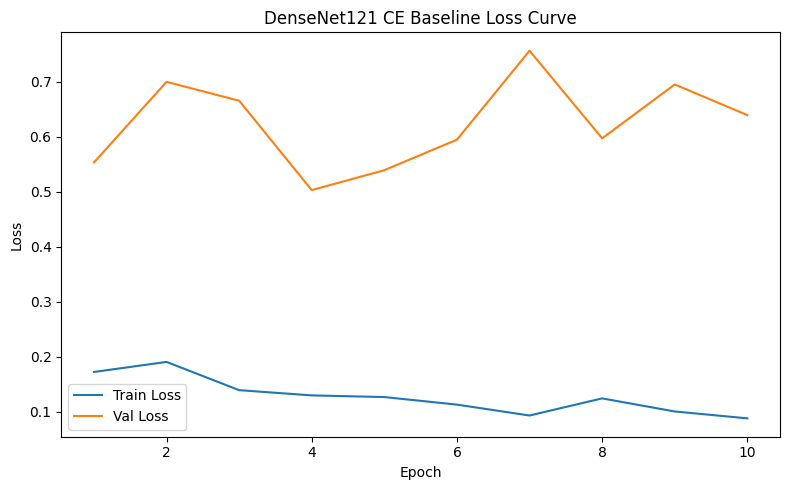

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_ce_baseline_loss.png


In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 CE Baseline Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_baseline_loss.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [28]:
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics
# train set
val_loss, val_metrics, val_true, val_pred = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
)

print_metrics(val_metrics, title="Validation Metrics")


Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Validation Metrics
accuracy: 0.8425
macro_f1: 0.8258
weighted_f1: 0.8404
mae: 0.2055
qwk: 0.9177
total_errors: 23
adjacent_errors: 18
distant_errors: 5
total_error_rate: 0.1575
adjacent_error_rate: 0.1233
distant_error_rate: 0.0342


In [30]:
from utils.metrics import get_classification_report


# test set
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print_metrics(test_metrics, title="Test Metrics")


#classification report 
report = get_classification_report(
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
)

print(report)


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Test Metrics
accuracy: 0.7687
macro_f1: 0.7604
weighted_f1: 0.7701
mae: 0.3027
qwk: 0.8666
total_errors: 68
adjacent_errors: 54
distant_errors: 14
total_error_rate: 0.2313
adjacent_error_rate: 0.1837
distant_error_rate: 0.0476
              precision    recall  f1-score   support

     0Normal       0.87      0.85      0.86        91
   1Doubtful       0.74      0.69      0.72        88
       2Mild       0.60      0.82      0.69        38
   3Moderate       0.71      0.86      0.78        35
     4Severe       0.93      0.64      0.76        42

    accuracy                           0.77       294
   macro avg       0.77      0.77      0.76       294
weighted avg       0.79      0.77      0.77       294



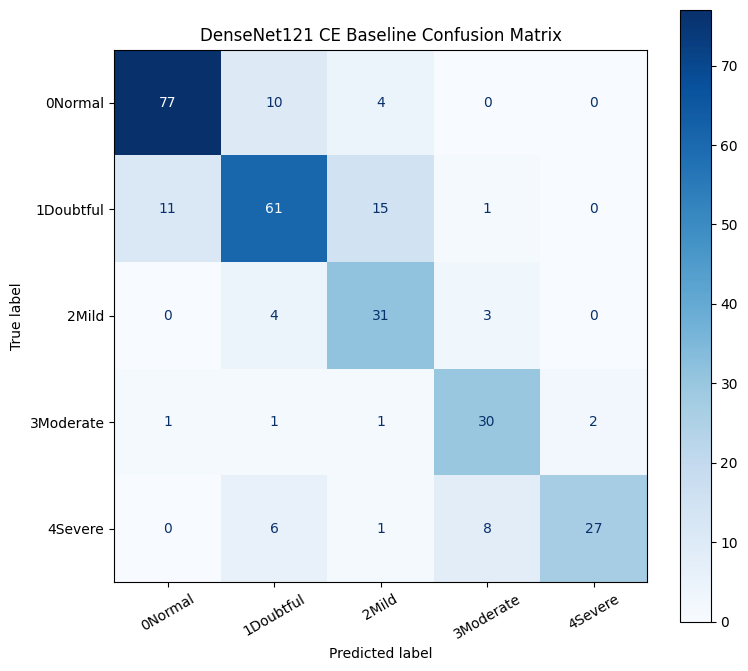

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_ce_baseline_confusion_matrix.png


In [32]:
# Confusion matrix
from utils.metrics import get_confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 CE Baseline Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_baseline_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)
